In [11]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
qubit_counts = [2,3,4,5,6,7,8,10,12,14,16]

n_layers = 2
n_trials = 750

In [13]:
def create_circuitZ(n_qubits, n_layers):

    dev = qml.device("lightning.qubit",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuitZ(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q,0],wires=q)
                qml.RZ(weights[layer, q,1],wires=q)
            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])
                
        return qml.expval(qml.PauliZ(0))
    return circuitZ

In [14]:
def create_circuitY(n_qubits, n_layers):

    dev = qml.device("lightning.qubit",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuitY(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q,0],wires=q)
                qml.RZ(weights[layer, q,1],wires=q)
            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])
                
        return qml.expval(qml.PauliY(0))
    return circuitY

In [15]:
def create_circuitX(n_qubits, n_layers):

    dev = qml.device("lightning.qubit",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuitX(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q,0],wires=q)
                qml.RZ(weights[layer, q,1],wires=q)
            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])
                
        return qml.expval(qml.PauliX(0))
    return circuitX

In [16]:
def run_experimentZ(n_qubits, n_layers, n_trials):

    circuitZ = create_circuitZ(n_qubits,n_layers)
    
    all_gradients = []
    
    
    for trial in range(n_trials):
        weights = np.array(np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits,2)),requires_grad=True)
        gradientZ = qml.grad(circuitZ)(weights)
        all_gradients.append(gradientZ)
    
    return np.array(all_gradients)

In [17]:
def run_experimentY(n_qubits, n_layers, n_trials):

    circuitY = create_circuitY(n_qubits,n_layers)
    
    all_gradients = []
    
    
    for trial in range(n_trials):
        weights = np.array(np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits,2)),requires_grad=True)
        gradientY = qml.grad(circuitY)(weights)
        all_gradients.append(gradientY)
    
    return np.array(all_gradients)

In [18]:
def run_experimentX(n_qubits, n_layers, n_trials):

    circuitX = create_circuitX(n_qubits,n_layers)
    
    all_gradients = []
    
    for trial in range(n_trials):
        weights = np.array(np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits,2)),requires_grad=True)
        gradientX = qml.grad(circuitX)(weights)
        all_gradients.append(gradientX)
    
    return np.array(all_gradients)

In [19]:
results = []
    
for n_qubits in qubit_counts:

    print(f"Running {n_qubits} qubits...")
    print(f"Running X")
    gradientsX = run_experimentX(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)
    parameter_varX = np.var(gradientsX,axis=0)
    RY_varX = np.mean(parameter_varX[:,:,0])
    RZ_varX = np.mean(parameter_varX[:,:,1])

    results.append({"Observ": "X","Qubits": n_qubits,"RY Variance": RY_varX,"RZ Variance": RZ_varX})

    print(f"Running Y")
    gradientsY = run_experimentY(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)
    parameter_varY = np.var(gradientsY,axis=0)
    RY_varY = np.mean(parameter_varY[:,:,0])
    RZ_varY = np.mean(parameter_varY[:,:,1])

    results.append({"Observ": "Y","Qubits": n_qubits,"RY Variance": RY_varY,"RZ Variance": RZ_varY})

    print(f"Running Z")
    gradientsZ = run_experimentZ(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)
    parameter_varZ = np.var(gradientsZ,axis=0)
    RY_varZ = np.mean(parameter_varZ[:,:,0])
    RZ_varZ = np.mean(parameter_varZ[:,:,1])

    results.append({"Observ": "Z","Qubits": n_qubits,"RY Variance": RY_varZ,"RZ Variance": RZ_varZ})

Running 2 qubits...
Running X
Running Y
Running Z
Running 3 qubits...
Running X
Running Y
Running Z
Running 4 qubits...
Running X
Running Y
Running Z
Running 5 qubits...
Running X
Running Y
Running Z
Running 6 qubits...
Running X
Running Y
Running Z
Running 7 qubits...
Running X
Running Y
Running Z
Running 8 qubits...
Running X
Running Y
Running Z
Running 10 qubits...
Running X
Running Y
Running Z
Running 12 qubits...
Running X
Running Y
Running Z
Running 14 qubits...
Running X
Running Y
Running Z
Running 16 qubits...
Running X
Running Y
Running Z


,Observ,Qubits,RY Variance,RZ Variance
0,X,2,0.10989384361765625,0.12681959579255325
1,Y,2,0.11201842000459035,0.12322537966563568
2,Z,2,0.1478904406517904,0.016569303191958637
3,X,3,0.04100054654657148,0.042847514625744515
4,Y,3,0.03993367371077551,0.040808525055545414
5,Z,3,0.10086653052618565,0.010823361590374544
6,X,4,0.03016079931111986,0.02881221089415903
7,Y,4,0.0296733952848431,0.029061494270698974
8,Z,4,0.0754406929734649,0.007691346181021714
9,X,5,0.024319943299535046,0.024494735763734562


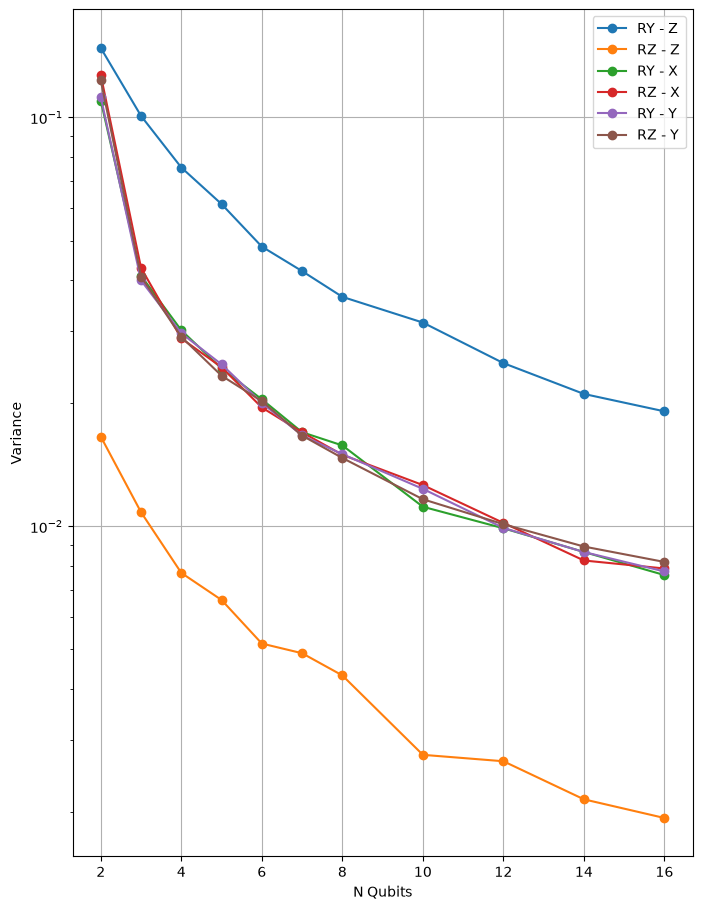

In [20]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(8,len(qubit_counts)))


data = results_df[results_df["Observ"] == "Z"]
plt.plot(data["Qubits"],data["RY Variance"],marker="o",label="RY - Z")
plt.plot(data["Qubits"],data["RZ Variance"],marker="o",label="RZ - Z")

data = results_df[results_df["Observ"] == "X"]
plt.plot(data["Qubits"],data["RY Variance"],marker="o",label="RY - X")
plt.plot(data["Qubits"],data["RZ Variance"],marker="o",label="RZ - X")


data = results_df[results_df["Observ"] == "Y"]
plt.plot(data["Qubits"],data["RY Variance"],marker="o",label="RY - Y")
plt.plot(data["Qubits"],data["RZ Variance"],marker="o",label="RZ - Y")

plt.yscale("log")

plt.xlabel("N Qubits")
plt.ylabel("Variance")

plt.grid(True)
plt.legend()
plt.show()